# **EDA dataset Transacciones**

---



Importar Librerias

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

Cargar Dataset

In [ ]:
df = pd.read_csv("/content/dataset_transacciones_latam_final_8000.csv")

Visualizamos Dataset

In [ ]:
df.head()

,descripcion,categoria
0,SAGA FALABELLA AUT641073,Compras
1,DEB BATA,Compras
2,COMPRA JOCKEY PLAZA,Compras
3,TRANSF A TAXI DATUM,Transporte
4,IBERDROLA SEP,Servicios


Verificamos tamaño

In [ ]:
df.shape

(8000, 2)

Información General

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   descripcion  8000 non-null   object
 1   categoria    8000 non-null   object
dtypes: object(2)
memory usage: 125.1+ KB


In [ ]:
df.describe(include="all")

,descripcion,categoria
count,8000,8000
unique,8000,9
top,COPA AIRLINES.COM,Alimentación
freq,1,1600


Revisamos nombre de las columnas

In [ ]:
df.columns

Index(['descripcion', 'categoria'], dtype='object')

Buscamos valores nulos

In [ ]:
df.isnull().sum()

,0
descripcion,0
categoria,0


In [ ]:
(df.isnull().mean()*100).round(2)

,0
descripcion,0.0
categoria,0.0


Buscamos duplicados

In [ ]:
df.duplicated().sum()

np.int64(0)

Numero de categorías únicas

In [ ]:
df["categoria"].nunique()

9

In [ ]:
sorted(df["categoria"].unique())

['Alimentación',
 'Compras',
 'Educación',
 'Ocio',
 'Otros',
 'Salud',
 'Servicios',
 'Transporte',
 'Vivienda']

Distribución de categorías

In [ ]:
conteo = df["categoria"].value_counts()

conteo

,count
categoria,
Alimentación,1600
Compras,1400
Transporte,1200
Servicios,1200
Ocio,900
Salud,700
Vivienda,500
Educación,300
Otros,200


Visualización Gráfica de Categorías

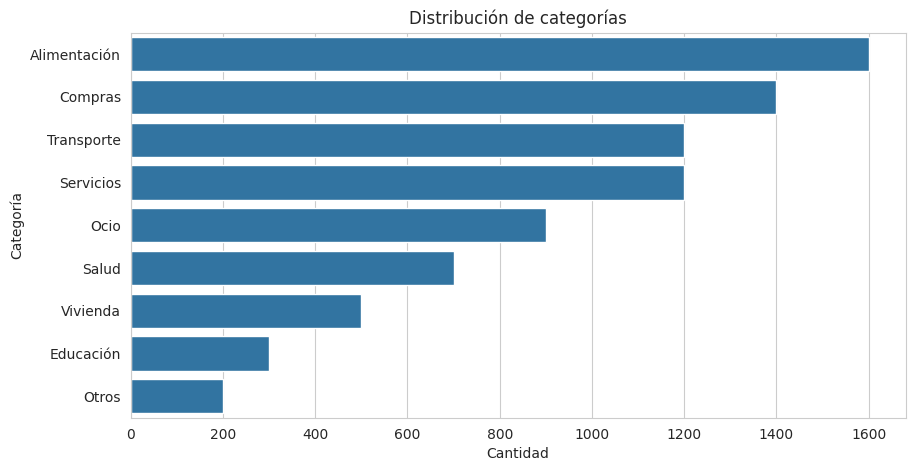

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="categoria",
    order=df["categoria"].value_counts().index
)

plt.title("Distribución de categorías")
plt.xlabel("Cantidad")
plt.ylabel("Categoría")

plt.show()

Porcentaje de categorías

In [ ]:
(
    df["categoria"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

,proportion
categoria,
Alimentación,20.00
Compras,17.50
Transporte,15.00
Servicios,15.00
Ocio,11.25
Salud,8.75
Vivienda,6.25
Educación,3.75
Otros,2.50


Revisar Ejemplos de cada Categoría

In [ ]:
for categoria in df["categoria"].unique():

    print("="*60)
    print(categoria)
    print("="*60)

    display(
        df[df["categoria"]==categoria]
        .sample(5, random_state=42)
    )

Compras


,descripcion,categoria
3865,H&M #099376,Compras
3634,TRX PLAZA VESTIR,Compras
586,APPLE.COM APROB240844,Compras
2772,OECHSLE NOV,Compras
1304,PLAZA VEA SHOP STORE,Compras


Transporte


,descripcion,categoria
7846,IN DRIVER SAN ISIDRO,Transporte
5902,RETIRO PARKING PLUS,Transporte
776,DEB LATAM AIRLINES,Transporte
3187,CRUZ DEL SUR REF650758,Transporte
444,G500 LATAM,Transporte


Servicios


...

,descripcion,categoria
5370,DB INSTITUTO CIBERTEC,Educación
7139,TRX PAGO MATRICULA,Educación
4118,LINKEDIN LEARNING LIMA,Educación
259,INSTITUTO CIBERTEC TARJETA 4316,Educación
6232,INSTITUTO IDIOMAS*283666,Educación


Vivienda


,descripcion,categoria
5802,RETIRO TRUPER FERRETERIA,Vivienda
1389,RETIRO ADMINISTRACION CONJUNTO RESIDENCIAL,Vivienda
6033,TRUPER FERRETERIA AUTORIZ 335677,Vivienda
2825,ADMINISTRACION EDIFICIO LATAM,Vivienda
1886,CARGO TRUPER FERRETERIA,Vivienda


Salud


,descripcion,categoria
1677,COMPRA POS ANALISIS CLINICOS UNIDOS,Salud
5600,ANALISIS CLINICOS UNIDOS LIMA,Salud
4463,OPTICA GMO*037554,Salud
1639,FARMATODO SAN ISIDRO,Salud
3631,DEB SALCOBRAND,Salud


Creamos una columna temporal para ver la longitud de las descripciones

In [ ]:
df["longitud"] = df["descripcion"].str.len()

In [ ]:
df["longitud"].describe()

,longitud
count,8000.000000
mean,19.713250
std,6.724502
min,5.000000
25%,15.000000
50%,19.000000
75%,24.000000
max,51.000000


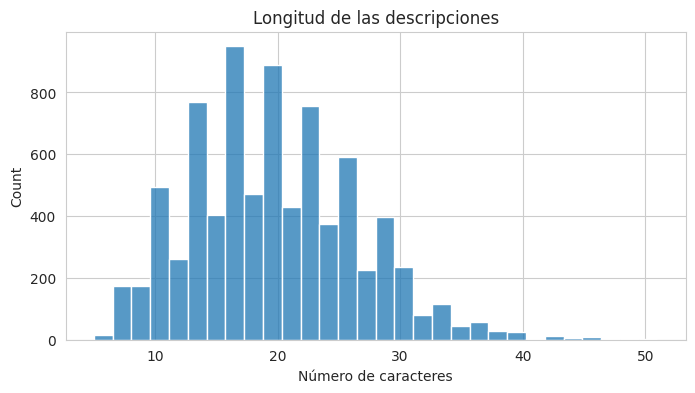

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(df["longitud"], bins=30)

plt.title("Longitud de las descripciones")
plt.xlabel("Número de caracteres")

plt.show()

Número de Palabras

In [ ]:
df["num_palabras"] = (
    df["descripcion"]
    .str.split()
    .str.len()
)

In [ ]:
df["num_palabras"].describe()

,num_palabras
count,8000.000000
mean,2.976625
std,0.971955
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,7.000000


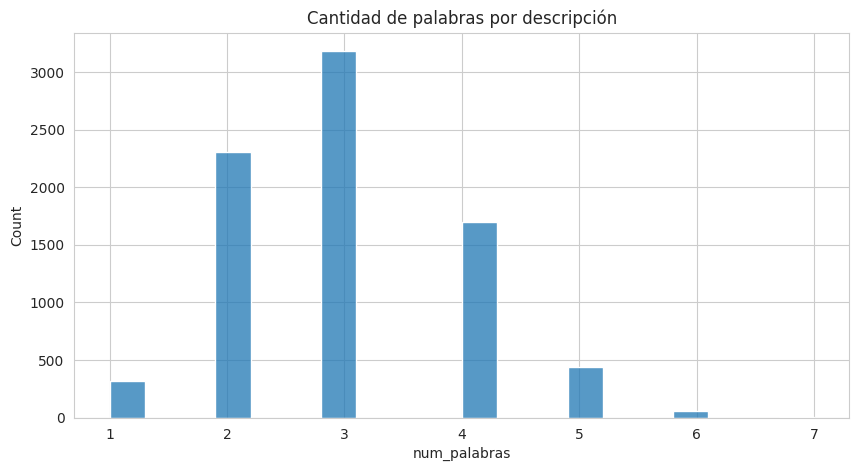

In [ ]:
sns.histplot(df["num_palabras"], bins=20)

plt.title("Cantidad de palabras por descripción")

plt.show()

Revisamos las descripciones mas cortas

In [ ]:
df.sort_values("num_palabras").head(20)

,descripcion,categoria,longitud,num_palabras
375,MODO*CAYETANO,Servicios,13,1
7180,PEMEX*837782,Transporte,12,1
7178,EBAY.COM,Compras,8,1
7193,TEMU.COM,Compras,8,1
7142,MODO*AITANA,Servicios,11,1
7159,ARA.COM,Alimentación,7,1
403,MODO*EVANGELINA,Otros,15,1
7071,MODO*LOIDA,Servicios,10,1
460,CARUULLA.COM,Alimentación,12,1
454,ESTACIONAMIENTO.COM,Transporte,19,1


Descripciones más largas

In [ ]:
df.sort_values("num_palabras", ascending=False).head(20)

,descripcion,categoria,longitud,num_palabras
6209,NRO OP 836259 CENTRO MEDICO SAN FELIPE,Salud,38,7
6925,COMPRA CLINICA LAS AMERICAS MAR DEL PLATA,Salud,41,7
3023,COMPRA CENTRO MEDICO SAN FELIPE BUENOS AIRES,Salud,44,7
1411,PAGO SERV PARQUE DE LAS LEYENDAS,Ocio,32,6
683,PEAJE RUTAS DEL SOL TARJETA 0596,Transporte,32,6
6277,NRO OP 631809 CONCIERTO LIVE NATION,Ocio,35,6
7782,COMPRA IN DRIVER MAR DEL PLATA,Transporte,30,6
91,NRO OP 790915 LA POSITIVA SEGUROS,Servicios,33,6
1782,NRO OP 689827 ANALISIS CLINICOS UNIDOS,Salud,38,6
4205,COMPRA TC PARQUE DE LAS LEYENDAS,Ocio,32,6


Longitud promedio por categoría

In [ ]:
df.groupby("categoria")["num_palabras"].mean().sort_values()

,num_palabras
categoria,
Alimentación,2.606875
Servicios,2.781667
Compras,2.898571
Transporte,2.922500
Ocio,3.202222
Educación,3.253333
Otros,3.350000
Salud,3.501429
Vivienda,3.520000


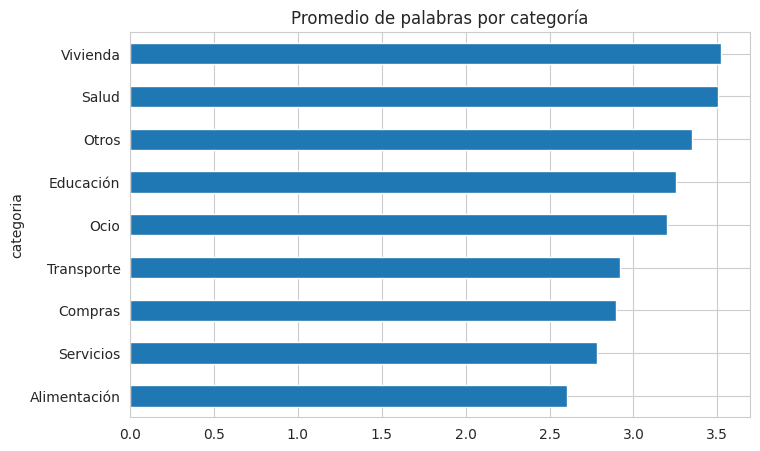

In [ ]:
(
    df.groupby("categoria")["num_palabras"]
      .mean()
      .sort_values()
      .plot.barh(figsize=(8,5))
)

plt.title("Promedio de palabras por categoría")

plt.show()

Palabras más frecuentes

In [ ]:
from collections import Counter

texto = " ".join(df["descripcion"])

palabras = texto.split()

Counter(palabras).most_common(30)

[('COMPRA', 939),
 ('PAGO', 607),
 ('ONLINE', 311),
 ('POS', 309),
 ('WEB', 286),
 ('STORE', 247),
 ('TARJETA', 233),
 ('NRO', 222),
 ('AUTORIZ', 219),
 ('OP', 219),
 ('SAN', 212),
 ('LIMA', 192),
 ('A', 185),
 ('TRANSF', 167),
 ('LATAM', 167),
 ('MIRAFLORES', 162),
 ('SEGUROS', 160),
 ('ISIDRO', 158),
 ('DB', 157),
 ('DEL', 157),
 ('PLAZA', 156),
 ('TRX', 156),
 ('VISA', 150),
 ('LA', 148),
 ('DEBITO', 148),
 ('DEB', 147),
 ('TC', 147),
 ('QR', 147),
 ('RETIRO', 146),
 ('AUTOMATICO', 146)]

Ver registros aleatorios

In [ ]:
df.sample(20, random_state=42)

,descripcion,categoria,longitud,num_palabras
2215,COMPRA SCOOTER MOVO TIJUANA,Transporte,27,4
2582,PARAMOUNT PLUS QR,Ocio,17,3
1662,MODO*ANA,Servicios,8,1
3027,NEQUI*MATEO 460078,Servicios,18,2
4343,FARMACIA BENAVIDES APROB125208,Salud,30,3
2680,KFC*500372,Alimentación,10,1
1765,PANADERIA SAN JORGE.COM,Alimentación,23,3
1123,COMPRA POS ENEX,Transporte,15,3
4054,PAGO ONLINE RETIRO CAJERO,Otros,25,4
3761,MUSEO INTERACTIVO MEDELLIN,Ocio,26,3


Eliminamos las columnas temporales

In [ ]:
df.drop(columns=["longitud", "num_palabras"], inplace=True)

Guardar el dataset validado

In [ ]:
df.to_csv("dataset_transacciones_validado.csv", index=False, encoding="utf-8")

In [ ]:
from google.colab import files

files.download("dataset_transacciones_validado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>